# Earnings Call Sentiment vs. Forward Returns — Retail/Consumer

Question: Does management tone on earnings calls predict forward stock returns?

Matplotlib is building the font cache; this may take a moment.


N = 31
Correlation (sentiment vs return_1d): 0.157
Correlation (sentiment vs return_5d): 0.048
Correlation (sentiment vs return_30d): 0.047


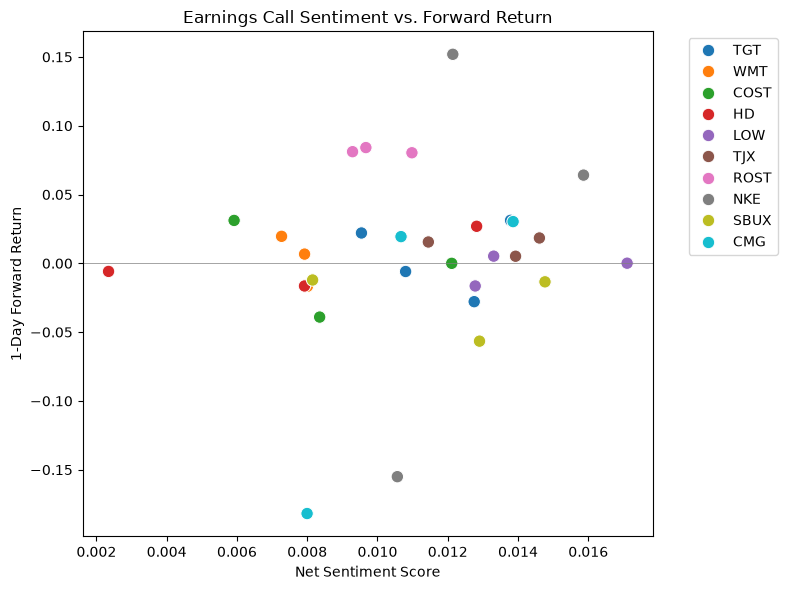

        return_1d  return_5d  return_30d
bucket                                  
Low     -0.010131  -0.007893    0.006492
Mid      0.014589   0.012097    0.052884
High     0.011140  -0.001658    0.007121

Excluding ['ROST', 'NKE', 'CMG'] (n=22):
Correlation: 0.002
Correlation: -0.152
Correlation: 0.096


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/results.csv')
print(f"N = {len(df)}")

for horizon in ['return_1d', 'return_5d', 'return_30d']:
    corr = df['net_sentiment'].corr(df[horizon])
    print(f"Correlation (sentiment vs {horizon}): {corr:.3f}")

fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df, x='net_sentiment', y='return_1d', hue='ticker', s=80, ax=ax)
ax.set_xlabel('Net Sentiment Score')
ax.set_ylabel('1-Day Forward Return')
ax.set_title('Earnings Call Sentiment vs. Forward Return')
ax.axhline(0, color='gray', linewidth=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../data/processed/sentiment_scatter.png', dpi=150)
plt.show()

df['bucket'] = pd.qcut(df['net_sentiment'], 3, labels=['Low', 'Mid', 'High'])
print(df.groupby('bucket')[['return_1d','return_5d','return_30d']].mean())

outliers = ['ROST', 'NKE', 'CMG']
df_robust = df[~df['ticker'].isin(outliers)]
print(f"\nExcluding {outliers} (n={len(df_robust)}):")
for horizon in ['return_1d', 'return_5d', 'return_30d']:
    corr = df_robust['net_sentiment'].corr(df_robust[horizon])
    print(f"Correlation: {corr:.3f}")

In [ ]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from companies import COMPANIES, TRANSCRIPT_LOG
from fetch_prices import build_returns_dataset
from sentiment_lexicon import LexiconScorer
from sentiment_llm import score_batch

sns.set_style('whitegrid')

## Step 1: Load transcripts and compute sentiment scores

Fill in `TRANSCRIPT_LOG` in `src/companies.py` first, then run this.

In [ ]:
# Lexicon-based scoring
# scorer = LexiconScorer('../data/loughran_mcdonald_dict.csv')
#
# lexicon_results = []
# for entry in TRANSCRIPT_LOG:
#     with open(f"../data/transcripts/{entry['file']}") as f:
#         text = f.read()
#     scores = scorer.score(text)
#     lexicon_results.append({**entry, **scores})
#
# lexicon_df = pd.DataFrame(lexicon_results)
# lexicon_df.head()

In [ ]:
# LLM-based scoring (requires ANTHROPIC_API_KEY set)
# llm_results = score_batch(TRANSCRIPT_LOG)
# llm_df = pd.DataFrame(llm_results)
# llm_df.head()

## Step 2: Pull forward returns

In [ ]:
# returns_df = build_returns_dataset(TRANSCRIPT_LOG)
# returns_df.head()

## Step 3: Merge sentiment + returns

In [ ]:
# merged = lexicon_df.merge(llm_df[['ticker','quarter','llm_sentiment']], on=['ticker','quarter'])
# merged = merged.merge(returns_df, on=['ticker','quarter'])
# merged.head()

## Step 4: Visualize the relationship

In [ ]:
# fig, ax = plt.subplots(figsize=(8,6))
# sns.scatterplot(data=merged, x='net_sentiment', y='return_5d', hue='segment', ax=ax)
# ax.set_xlabel('Lexicon Net Sentiment')
# ax.set_ylabel('5-Day Forward Return')
# ax.set_title('Sentiment vs. Forward Return')
# plt.show()

## Step 5: Bucket analysis

In [ ]:
# merged['sentiment_bucket'] = pd.qcut(merged['net_sentiment'], 3, labels=['Negative','Neutral','Positive'])
# merged.groupby('sentiment_bucket')['return_5d'].mean()

## Findings

_(Write up what you found here once the analysis runs — including if the result is a null finding.)_